In [2]:
"""
Utility script to quickly view tonemapped images directly from a packed HDF5 chunk file, 
without needing the heavy raw EXR files on disk.

Usage:
    python data_generation/view_h5.py renderformer/tmp/dataset_single_obj_v2/nmr_dataset_chunk_0000.h5 --scene scene_0000
"""

import os
import argparse
import h5py
import numpy as np
import matplotlib.pyplot as plt

def hdr_to_ldr(hdr_img, gamma=2.2):
    """Simple tonemapping by applying gamma correction and clipping."""
    # Prevent negative values before power
    ldr = np.clip(hdr_img, 0, None)
    ldr = np.power(ldr, 1.0 / gamma)
    ldr = np.clip(ldr, 0, 1)
    return ldr

def view_scenes(h5_path, scene=None):

    if not os.path.exists(h5_path):
        print(f"Error: File {h5_path} does not exist.")
        return

    with h5py.File(h5_path, 'r') as f:
        scenes = list(f.keys())
        if not scenes:
            print("Error: H5 file is empty.")
            return
            
        scene_name = scene
        if scene_name is None:
            scene_name = scenes[0]
            print(f"No scene specified. Defaulting to first scene: {scene_name}")
            
        scene_name_suffixes = [int(s.split('_')[-1]) for s in scenes]
        min_idx, max_idx = min(scene_name_suffixes), max(scene_name_suffixes)
        print(f"Available scenes: {len(scenes)}. Scene index range: {min_idx} to {max_idx}")
        if scene_name not in f:
            print(f"Error: Scene '{scene_name}' not found. Some available scenes: {scenes[:5]}....")
            return

        grp = f[scene_name]
        if 'hdr_target_image' not in grp:
            print(f"Error: 'hdr_target_image' dataset not found in {scene_name}")
            return

        # Shape: [num_views, H, W, C]
        hdr_images = grp['hdr_target_image'][:]

        
    num_views = hdr_images.shape[0]
    print(f"Loaded {num_views} views for {scene_name}.")
    
    # Plotting
    fig, axes = plt.subplots(1, num_views, figsize=(4 * num_views, 4))
    if num_views == 1:
        axes = [axes]
        
    for i in range(num_views):
        ldr_img = hdr_to_ldr(hdr_images[i])
        axes[i].imshow(ldr_img)
        axes[i].set_title(f"View {i}")
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()


Available scenes: 5. Scene index range: 0 to 4
Loaded 2 views for scene_000002.


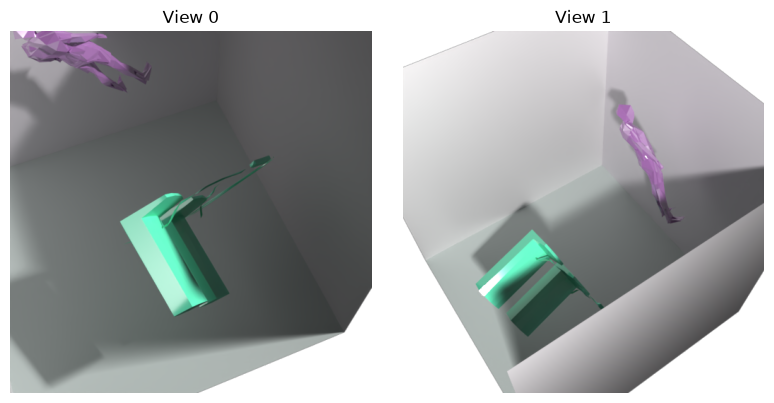

: 

In [ ]:
h5_path = "../tmp/dataset_test4_wallrandmaterial/nmr_dataset_chunk_0000.h5"
scene = "scene_000002"
view_scenes(h5_path=h5_path, scene=scene)

Available scenes: 500. Scene index range: 15000 to 15589
Loaded 4 views for scene_015300.


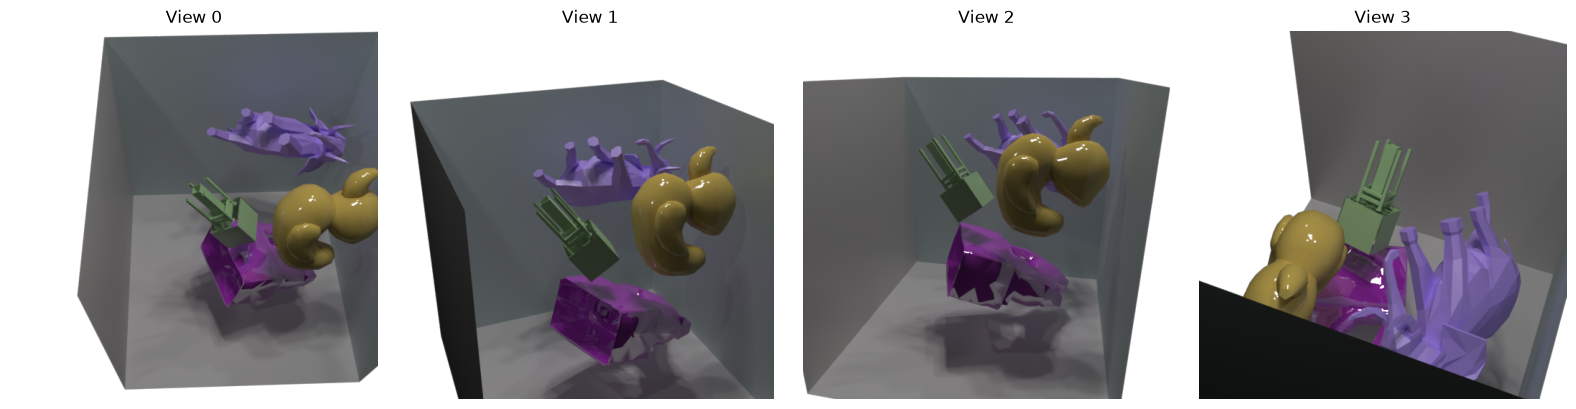

In [13]:
h5_path = "/storage/sazhang/datasets/dataset_uniform/nmr_dataset_chunk_0025.h5"
scene = "scene_015300"
view_scenes(h5_path=h5_path, scene=scene)

Available scenes: 473. Scene index range: 15000 to 15486
Loaded 4 views for scene_015486.


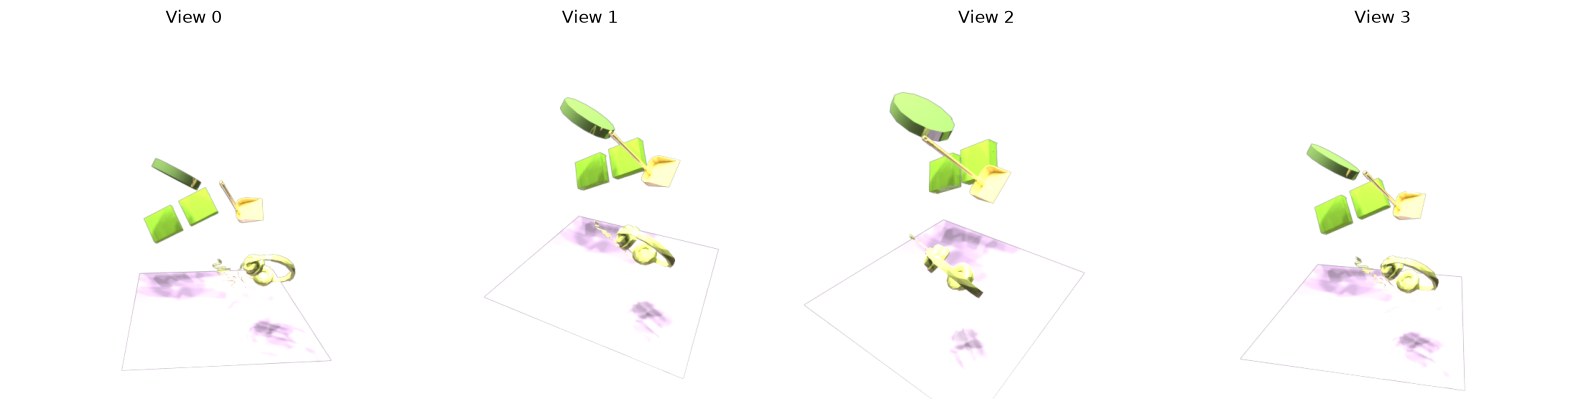

: 

In [ ]:
view_scenes(h5_path="/storage/sazhang/datasets/dataset_uniform/nmr_dataset_chunk_0025.h5.INCOMPLETE", scene="scene_015486")

In [1]:
from pathlib import Path
import re
import h5py


def print_chunk_scene_range(parent_dir, chunk_glob="nmr_dataset_chunk_*.h5"):
    print(f"Checking parent directory {parent_dir}...")
    parent_dir = Path(parent_dir)
    chunk_paths = sorted(parent_dir.glob(chunk_glob))

    if not chunk_paths:
        print(f"No chunk files matching {chunk_glob} found in {parent_dir}")
        return

    scene_indices = []
    scene_to_chunks = {}

    for chunk_path in chunk_paths:
        with h5py.File(chunk_path, "r") as handle:
            for scene_name in handle.keys():
                match = re.search(r"scene_(\d+)$", scene_name)
                if match is None:
                    continue
                scene_idx = int(match.group(1))
                scene_indices.append(scene_idx)
                scene_to_chunks.setdefault(scene_idx, []).append(chunk_path.name)

    if not scene_indices:
        print(f"No scene_* groups found in {len(chunk_paths)} chunk files under {parent_dir}")
        return

    scene_indices = sorted(set(scene_indices))
    min_scene = scene_indices[0]
    max_scene = scene_indices[-1]
    missing = [scene_idx for scene_idx in range(min_scene, max_scene + 1) if scene_idx not in scene_indices]

    print(f"Chunk files scanned: {len(chunk_paths)}")
    print(f"Scene index range: {min_scene} to {max_scene}")
    if missing:
        print(f"Created {max_scene - min_scene + 1 - len(missing)} scenes.\nMissing scenes ({len(missing)}): {missing}")
    else:
        print("Missing scenes: none")


# Example:
print_chunk_scene_range("/storage/sazhang/datasets/dataset_uniform")

# print_chunk_scene_range("/storage/sazhang/dataset_uniform")


Checking parent directory /storage/sazhang/datasets/dataset_uniform...
Chunk files scanned: 26
Scene index range: 0 to 15589
Created 15500 scenes.
Missing scenes (90): [15429, 15438, 15450, 15454, 15458, 15460, 15464, 15465, 15469, 15471, 15473, 15476, 15483, 15485, 15487, 15491, 15492, 15494, 15495, 15497, 15498, 15499, 15500, 15502, 15503, 15504, 15505, 15507, 15508, 15509, 15510, 15511, 15513, 15515, 15516, 15517, 15519, 15520, 15521, 15522, 15523, 15524, 15525, 15526, 15527, 15530, 15531, 15532, 15533, 15534, 15535, 15536, 15537, 15538, 15541, 15542, 15544, 15545, 15546, 15547, 15548, 15549, 15550, 15551, 15552, 15553, 15554, 15555, 15556, 15558, 15559, 15563, 15564, 15565, 15566, 15568, 15569, 15570, 15571, 15573, 15575, 15576, 15577, 15578, 15579, 15580, 15581, 15583, 15587, 15588]
